In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
%matplotlib inline
#Just looking at the Visual Coding Neuropixels right now to build simple model,
#see if it could be done and if it is a cool visualization to keep working on
#The EcephysProjectCache focus on how neurons respond to visual imput (no behavioral data, yet)

In [ ]:
import os
os.makedirs("C:/Users/grace/brain_data", exist_ok=True) #creating brain_data folder to store this

In [ ]:
cache = EcephysProjectCache.from_warehouse(manifest="C:/Users/grace/brain_data/manifest.json")
#connects code to Allen's public online data warehouse instead of downloading all the session data
sessions = cache.get_session_table()
session_id = sessions.index[0] 
#possibly look at specific sessions in future, 
#ones with better data we can take a look at and compare
session = cache.get_session_data(session_id)

units = session.units
spike_times = session.spike_times  
#each key is a specific unit/neuron number and values
# are array of timestamps every time neuron fired a spike during session
print("Session loaded successfully")
print("Structure present:", units['ecephys_structure_acronym'].unique())

c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning:

Session loaded successfully
Structure present: ['APN' 'DG' 'CA1' 'VISam' 'grey' 'VISpm' 'PO' 'LP' 'PoT' 'VISp' 'LGd'
 'CA3' 'VISl' 'VISrl']


In [ ]:
all_spike_times = np.concatenate(list(session.spike_times.values()))
#creating one big array of spike times and then below finds earliest and latest spike times across all neurons
# to find full duration of recording
t_start = all_spike_times.min()
t_end = all_spike_times.max()
print(f"Session runs from {t_start:.1f}s to {t_end:.1f}s")

Session runs from 11.9s to 9640.7s


In [ ]:
#creating function to compute firing rates over time
#loops through each neuron where uid is neuron's ID number and then finds number of times it's fired
def compute_firing_rates(spike_times, t_start, t_end, bin_size=1.0):
    bins = np.arange(t_start, t_end, bin_size)
    rates = {}
    for uid, spikes in spike_times.items():
        counts, _ = np.histogram(spikes, bins=bins) #counting how many spikes fall into each 1 sec bin
        rates[uid] = counts / bin_size #converting spike count into firing rate in spikes per sec(Hz)
    return rates, bins

all_rates, bins = compute_firing_rates(session.spike_times, t_start, t_end, bin_size=1.0)
print(f"Computed firing rates across {len(bins)-1} timesteps")

Computed firing rates across 9628 timesteps


In [ ]:
#Normalizing rates by creating another reusable function, scales neuron's firing rates between 0 and 1
def normalize_rates(rates_over_time):
    normalized = {}
    for uid, r in rates_over_time.items():
        rng = r.max() - r.min()
        normalized[uid] = (r - r.min()) / (rng + 1e-9) #add 1e-9 to prevent error by dividing by 0 if a neuron doesn't fire
    return normalized
#now can map firing rates with brightness during video
# with 0 completely dark and 1 fully bright
normalized = normalize_rates(all_rates)
print("Normalization complete")

Normalization complete


Rendering a frame

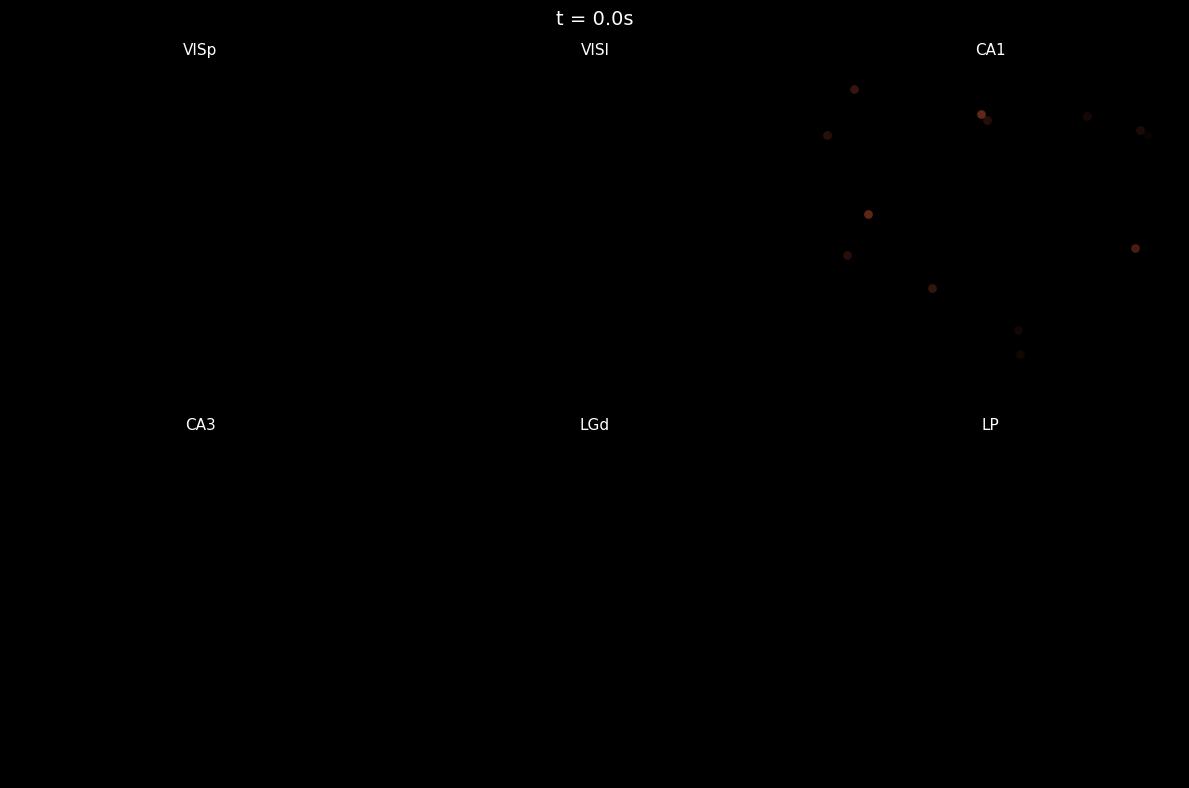

In [ ]:
REGIONS = ['VISp', 'VISl', 'CA1', 'CA3', 'LGd', 'LP']
COLORS  = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E', '#378ADD', '#639922']

#now creating each different frame from each timestep (t_idx)
def render_frame(units, norm_rates, t_idx, region_layout=(2, 3)):
    fig, axes = plt.subplots(*region_layout, figsize=(12, 8), facecolor='k')
    axes = axes.flatten()
    
    for ax, region, color in zip(axes, REGIONS, COLORS): #pairing each region and color
        ax.set_facecolor('k')
        ax.set_title(region, color='white', fontsize=11)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.axis('off')
        
        region_units = units[units['ecephys_structure_acronym'] == region] #only keep neurons that belong to said region
        n = len(region_units)
        if n == 0:
            continue
        
        # Grid layout of dots
        xs = np.random.default_rng(42).uniform(0.05, 0.95, n) #makes random positions for each neuron's dot
        #maybe in future renditions of this can figure out how to place each neuron in it's
        # anatomically correct position to create a more accurate and descriptive visualization
        ys = np.random.default_rng(99).uniform(0.05, 0.95, n)
        
        for i, uid in enumerate(region_units.index):
            brightness = normalized.get(uid, np.zeros(1))[t_idx]
            ax.scatter(xs[i], ys[i], s=40,
                       color=color, alpha=float(brightness),
                       linewidths=0)
    
    fig.suptitle(f't = {t_idx:.1f}s', color='white', fontsize=14)
    fig.tight_layout()
    return fig
fig = render_frame(units, normalized, t_idx=0) #testing for a single frame
plt.show()

Writing the whole video

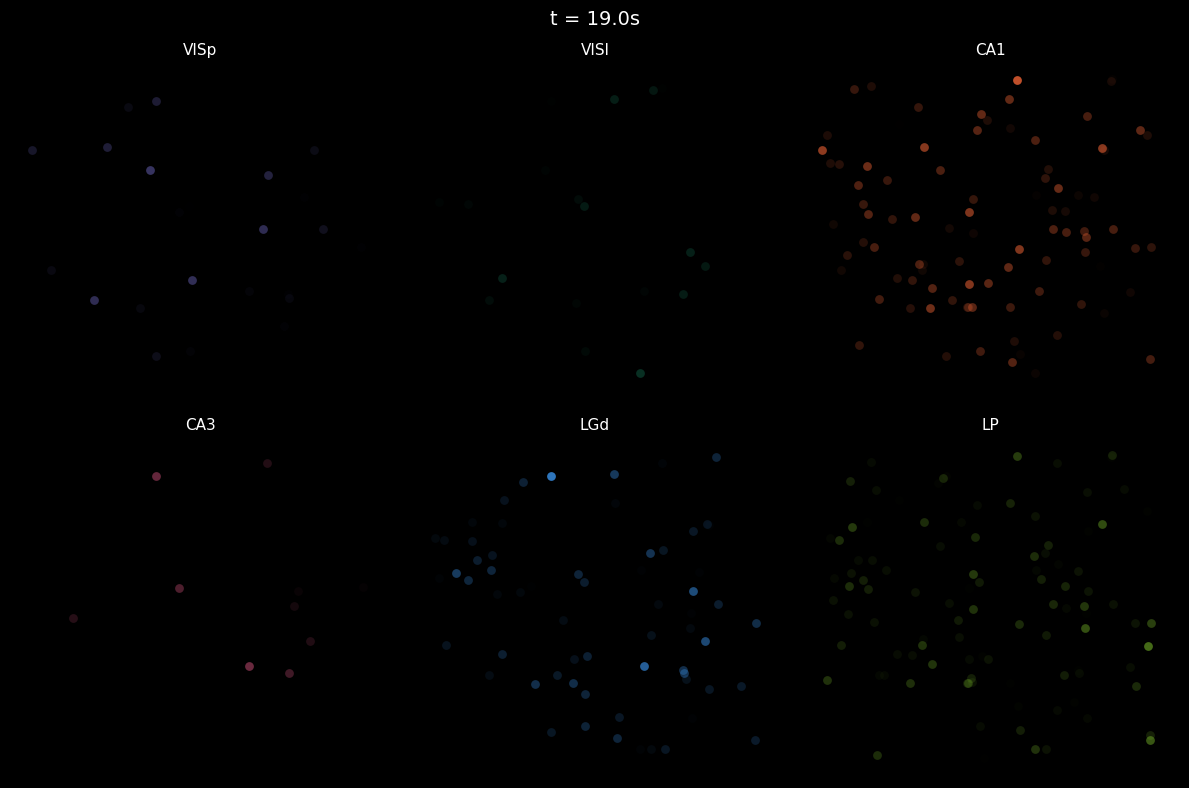

In [ ]:
from IPython.display import clear_output
import time #to add the pause feature
for t in range(0,20):
    fig = render_frame(units, normalized, t_idx=t)
    clear_output(wait=True) #erase previous frame from output before drawing next one
    plt.show()
    plt.close(fig)
    time.sleep(0.3) #pauses between frames for 0.3 seconds to see each one

In [ ]:
import imageio #to create video files
import io
from PIL import Image #Pillow image library for converting figures to arrays

test_frames = min(100, len(bins) -1) #Testing only 100 frames since attemping to render all
# 9,000 of them was going to take me multiple hours 
output_path = "C:/Users/grace/brain_data/brain_activity.mp4"
writer = imageio.get_writer(output_path, fps=1)

for t in range(test_frames):
    fig = render_frame(units, normalized, t_idx=t)
    buf = io.BytesIO() #creates an in-memory buffer, acts like file but lives in RAM vs. on disk
    fig.savefig(buf, format='png', facecolor='black')
    buf.seek(0) #rewinds buffer back to begining so can be read again
    frame = np.array(Image.open(buf)) #opens PNG from buffer and converts to array of pixel values
    writer.append_data(frame) #adds frame to video 
    plt.close(fig)
    buf.close()
    if t % 10==0: #prints progress update every 10 frames so can tack how far along the render is
        print(f"Rendered frame {t} of {len(bins)-1}")
writer.close() #saves the video file
print(f"Video saved to {output_path}")

Rendered frame 0 of 9628
Rendered frame 10 of 9628
Rendered frame 20 of 9628
Rendered frame 30 of 9628
Rendered frame 40 of 9628
Rendered frame 50 of 9628
Rendered frame 60 of 9628
Rendered frame 70 of 9628
Rendered frame 80 of 9628
Rendered frame 90 of 9628
Video saved to C:/Users/grace/brain_data/brain_activity.mp4


In [ ]:
from IPython.display import Video
Video(output_path, embed=True) #displays video file directly into notebook